This project implements a conditional 3D diffusion model for MRI modality translation (T1 to T2) using MONAI. The model is based on a Denoising Diffusion Probabilistic Model (DDPM), where Gaussian noise is progressively added to the target T2 images and a neural network is trained to predict and remove this noise.

A DiffusionModelUNet is used as the denoising backbone, operating directly in voxel space. The model is conditioned on T1 MRI volumes by concatenating them with the noisy T2 input. During training, the model learns to predict the noise added at each timestep using a mean squared error loss.

During inference, the model generates synthetic T2 images by iteratively denoising random noise conditioned on T1 input.

This approach is inspired by Stable Diffusion, but differs in that it operates in full image space instead of latent space, and uses MRI volumes as conditioning input instead of text embeddings.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!gdown --fuzzy "https://drive.google.com/file/d/1Ox7sCEqtM7gOM8Y72H1bqHULtWolfTu3/view?usp=sharing"

Mounted at /content/drive
Downloading...
From (original): https://drive.google.com/uc?id=1Ox7sCEqtM7gOM8Y72H1bqHULtWolfTu3
From (redirected): https://drive.google.com/uc?id=1Ox7sCEqtM7gOM8Y72H1bqHULtWolfTu3&confirm=t&uuid=a644409d-b94f-4230-8668-a49c187fa41b
To: /content/final-clean-data.zip
100% 2.28G/2.28G [00:57<00:00, 39.4MB/s]


In [2]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [3]:
!unzip "/content/final-clean-data.zip" -d "/content/dataset"

Archive:  /content/final-clean-data.zip
   creating: /content/dataset/final-clean-data/
   creating: /content/dataset/final-clean-data/T1/
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_001_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_002_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_003_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_004_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_005_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_006_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_007_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_008_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_009_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_010_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Tra

In [3]:
!pip install -q monai nibabel matplotlib tqdm
!pip install -q "monai-generative"
!pip install monai-generative
!pip install lpips

# **Data Preparation**



In [4]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import random
from pathlib import Path

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ResizeWithPadOrCropd,
    EnsureTyped,
    RandFlipd,
    RandRotate90d,
    RandAffined
)
from monai.data import Dataset
from monai.utils import set_determinism

from generative.networks.nets import DiffusionModelUNet
from generative.networks.schedulers import DDPMScheduler
import os
import shutil
import tempfile

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from monai import transforms
from monai.apps import DecathlonDataset
from monai.config import print_config
from monai.data import DataLoader
from monai.utils import first, set_determinism
from torch.cuda.amp import GradScaler, autocast
from torch.nn import L1Loss
from tqdm import tqdm

from generative.inferers import LatentDiffusionInferer
from generative.losses import PatchAdversarialLoss, PerceptualLoss
from generative.networks.nets import AutoencoderKL, DiffusionModelUNet, PatchDiscriminator
from generative.networks.schedulers import DDPMScheduler

In [5]:
set_determinism(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Update these paths
t1_dir = Path("/content/dataset/final-clean-data/T1")
t2_dir = Path("/content/dataset/final-clean-data/T2")

output_dir = Path("/content/drive/MyDrive/fyp_ldm_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Start smaller first if using Colab T4
spatial_size = (96, 96, 96)
batch_size = 4
num_workers = 8

ae_epochs = 50
diff_epochs = 100

ae_lr = 1e-4
diff_lr = 5e-4

num_train_timesteps = 1000

Using device: cuda


In [6]:
def build_paired_data(t1_dir: Path, t2_dir: Path):
    t1_files = sorted(t1_dir.glob("*.nii*"))
    pairs = []

    for t1_path in t1_files:
        t2_name = t1_path.name.replace("_t1", "_t2")
        t2_path = t2_dir / t2_name

        if t2_path.exists():
            pairs.append({
                "t1": str(t1_path),
                "t2": str(t2_path),
                "id": t1_path.stem.replace("_t1", "")
            })

    if len(pairs) == 0:
        raise ValueError("No paired T1/T2 files found. Check folder paths and naming.")

    return pairs

data_dicts = build_paired_data(t1_dir, t2_dir)
print("Total paired cases:", len(data_dicts))
print(data_dicts)

Total paired cases: 494
[{'t1': '/content/dataset/final-clean-data/T1/BraTS20_Training_001_t1.nii', 't2': '/content/dataset/final-clean-data/T2/BraTS20_Training_001_t2.nii', 'id': 'BraTS20_Training_001'}, {'t1': '/content/dataset/final-clean-data/T1/BraTS20_Training_002_t1.nii', 't2': '/content/dataset/final-clean-data/T2/BraTS20_Training_002_t2.nii', 'id': 'BraTS20_Training_002'}, {'t1': '/content/dataset/final-clean-data/T1/BraTS20_Training_003_t1.nii', 't2': '/content/dataset/final-clean-data/T2/BraTS20_Training_003_t2.nii', 'id': 'BraTS20_Training_003'}, {'t1': '/content/dataset/final-clean-data/T1/BraTS20_Training_004_t1.nii', 't2': '/content/dataset/final-clean-data/T2/BraTS20_Training_004_t2.nii', 'id': 'BraTS20_Training_004'}, {'t1': '/content/dataset/final-clean-data/T1/BraTS20_Training_005_t1.nii', 't2': '/content/dataset/final-clean-data/T2/BraTS20_Training_005_t2.nii', 'id': 'BraTS20_Training_005'}, {'t1': '/content/dataset/final-clean-data/T1/BraTS20_Training_006_t1.nii', 

In [7]:
#split the dataset 80-10-10
random.shuffle(data_dicts)

n = len(data_dicts)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_files = data_dicts[:train_end]
val_files = data_dicts[train_end:val_end]
test_files = data_dicts[val_end:]

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 395
Val: 49
Test: 50


In [8]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    CropForegroundd,
    SpatialPadd,
    CenterSpatialCropd,
    ScaleIntensityRangePercentilesd,
    EnsureTyped,
)

transforms_3d = Compose([
    LoadImaged(keys=["t1", "t2"]),
    EnsureChannelFirstd(keys=["t1", "t2"]),
    EnsureTyped(keys=["t1", "t2"]),
    Orientationd(keys=["t1", "t2"], axcodes="RAS"),
    Spacingd(
        keys=["t1", "t2"],
        pixdim=(1.5, 1.5, 1.5),
        mode=("bilinear", "bilinear")
    ),
    CropForegroundd(keys=["t1", "t2"], source_key="t1"),
    SpatialPadd(keys=["t1", "t2"], spatial_size=(96, 96, 64)),
    CenterSpatialCropd(keys=["t1", "t2"], roi_size=(96, 96, 64)),
    ScaleIntensityRangePercentilesd(
        keys=["t1", "t2"],
        lower=0,
        upper=99.5,
        b_min=-1.0,
        b_max=1.0,
        clip=True,
    ),
    RandFlipd(keys=["t1", "t2"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["t1", "t2"], prob=0.5, spatial_axis=1),

    RandRotate90d(keys=["t1", "t2"], prob=0.5, max_k=3),

    RandAffined(
        keys=["t1", "t2"],
        prob=0.3,
        rotate_range=(0.1, 0.1, 0.1),
        scale_range=(0.1, 0.1, 0.1),
    ),
])

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [9]:
from monai.transforms import LoadImaged, EnsureChannelFirstd, Compose
from monai.data import Dataset
from torch.utils.data import DataLoader

train_ds = Dataset(data=train_files, transform=transforms_3d)
val_ds = Dataset(data=val_files, transform=transforms_3d)
test_ds = Dataset(data=test_files, transform=transforms_3d)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=num_workers)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 99
Val batches: 49
Test batches: 50


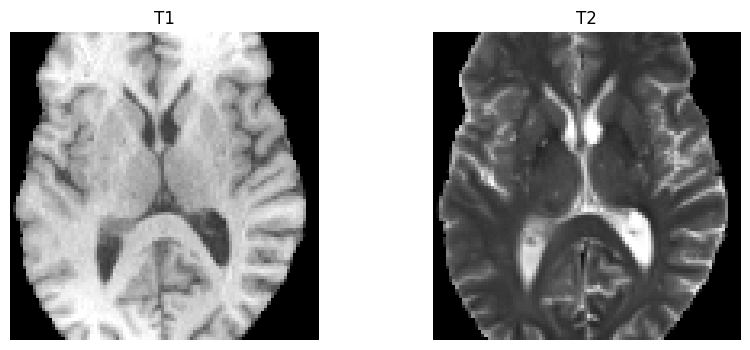

T1 shape: torch.Size([4, 1, 96, 96, 64])
T2 shape: torch.Size([4, 1, 96, 96, 64])


In [12]:
#visualize one sample
batch = next(iter(train_loader))
t1 = batch["t1"][0, 0].cpu().numpy()
t2 = batch["t2"][0, 0].cpu().numpy()

z = t1.shape[2] // 2

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(t1[:, :, z], cmap="gray")
plt.title("T1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(t2[:, :, z], cmap="gray")
plt.title("T2")
plt.axis("off")
plt.show()

print("T1 shape:", batch["t1"].shape)
print("T2 shape:", batch["t2"].shape)

Autoencoder

In [10]:
from generative.inferers import LatentDiffusionInferer
from generative.networks.nets import AutoencoderKL, DiffusionModelUNet, PatchDiscriminator
from generative.networks.schedulers import DDPMScheduler

In [11]:
autoencoder = AutoencoderKL(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    num_channels=(64, 128, 256),
    latent_channels=8,
    num_res_blocks=2,
    norm_num_groups=16,
    attention_levels=(False, False, True),
).to(device)

kl_weight = 1e-6
perceptual_weight = 0
adv_weight = 0
autoencoder_warm_up_n_epochs = 30

Define loss

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

autoencoder.to(device)


optimizer_g = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)


l1_loss = L1Loss()
adv_loss = PatchAdversarialLoss(criterion="least_squares")

loss_perceptual = PerceptualLoss(
    spatial_dims=3,
    network_type="squeeze",
    is_fake_3d=True,
    fake_3d_ratio=0.2,
).to(device)

def KL_loss(z_mu, z_sigma):
    eps = 1e-8
    kl = 0.5 * torch.sum(
        z_mu.pow(2) + z_sigma.pow(2) - torch.log(z_sigma.pow(2) + eps) - 1,
        dim=[1, 2, 3, 4],
    )
    return kl.mean()


scaler_g = GradScaler(enabled=(device.type == "cuda"))
scaler_d = GradScaler(enabled=(device.type == "cuda"))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 187MB/s]
/tmp/ipykernel_8822/3174427730.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_g = GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_8822/3174427730.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_d = GradScaler(enabled=(device.type == "cuda"))


In [ ]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

@torch.no_grad()
def validate_autoencoder(autoencoder, val_loader, device):
    autoencoder.eval()

    val_recon_loss = 0.0
    val_psnr = []
    val_ssim = []
    num_batches = 0

    progress_bar = tqdm(val_loader, total=len(val_loader), ncols=110, desc="Validation", leave=False)

    for batch in progress_bar:
        t2 = batch["t2"].to(device)

        with autocast("cuda", enabled=(device.type == "cuda")):
            reconstruction, z_mu, z_sigma = autoencoder(t2)
            recon_loss = l1_loss(reconstruction.float(), t2.float())

        val_recon_loss += recon_loss.item()
        num_batches += 1

        recon_np = reconstruction.detach().cpu().numpy()
        gt_np = t2.detach().cpu().numpy()

        for i in range(recon_np.shape[0]):
            pred_vol = recon_np[i, 0]
            gt_vol = gt_np[i, 0]

            # clip in the true training range
            pred_vol = np.clip(pred_vol, -1.0, 1.0)
            gt_vol = np.clip(gt_vol, -1.0, 1.0)

            # rescale to [0, 1] for PSNR / SSIM
            pred_vol = (pred_vol + 1.0) / 2.0
            gt_vol = (gt_vol + 1.0) / 2.0

            psnr_val = psnr(gt_vol, pred_vol, data_range=1.0)
            val_psnr_list.append(psnr_val)

            ssim_slices = []
            for z in range(pred_vol.shape[2]):
                ssim_val = ssim(
                    gt_vol[:, :, z],
                    pred_vol[:, :, z],
                    data_range=1.0
                )
                ssim_slices.append(ssim_val)

            val_ssim_list.append(np.mean(ssim_slices))

        progress_bar.set_postfix({
            "val_recon_loss": val_recon_loss / max(num_batches, 1),
            "val_psnr": np.mean(val_psnr) if val_psnr else 0.0,
            "val_ssim": np.mean(val_ssim) if val_ssim else 0.0,
        })

    return (
        val_recon_loss / max(num_batches, 1),
        float(np.mean(val_psnr)) if val_psnr else 0.0,
        float(np.mean(val_ssim)) if val_ssim else 0.0,
    )

In [ ]:
import os
import numpy as np
import torch
from tqdm import tqdm
from google.colab import drive
from torch.amp import autocast, GradScaler
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# =========================================================
# 0. MOUNT GOOGLE DRIVE
# =========================================================
drive.mount("/content/drive")

save_dir = "/content/drive/MyDrive/fyp_checkpoints"
os.makedirs(save_dir, exist_ok=True)

latest_ckpt_path = os.path.join(save_dir, "autoencoder_latest.pth")
best_ckpt_path = os.path.join(save_dir, "autoencoder_best.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

autoencoder = autoencoder.to(device)


# =========================================================
# 1. TRAINING CONFIG
# =========================================================
n_epochs = 100
autoencoder_warm_up_n_epochs = 5
resume_training = False

# save best model by SSIM instead of only recon loss
best_val_ssim = -1.0
best_val_recon_loss = float("inf")

# =========================================================
# 2. AMP SCALERS
# =========================================================
scaler_g = GradScaler("cuda", enabled=(device.type == "cuda"))
scaler_d = GradScaler("cuda", enabled=(device.type == "cuda"))

# =========================================================
# 3. HISTORY
# =========================================================
start_epoch = 0

epoch_recon_loss_list = []
epoch_gen_loss_list = []
epoch_disc_loss_list = []

val_recon_epoch_loss_list = []
val_psnr_epoch_list = []
val_ssim_epoch_list = []

# =========================================================
# 4. OPTIONAL: RESUME FROM LATEST CHECKPOINT
# =========================================================
if resume_training and os.path.exists(latest_ckpt_path):
    checkpoint = torch.load(latest_ckpt_path, map_location=device)

    autoencoder.load_state_dict(checkpoint["autoencoder_state_dict"])

    optimizer_g.load_state_dict(checkpoint["optimizer_g_state_dict"])

    scaler_g.load_state_dict(checkpoint["scaler_g_state_dict"])
    scaler_d.load_state_dict(checkpoint["scaler_d_state_dict"])

    start_epoch = checkpoint["epoch"]
    epoch_recon_loss_list = checkpoint.get("epoch_recon_loss_list", [])
    epoch_gen_loss_list = checkpoint.get("epoch_gen_loss_list", [])
    epoch_disc_loss_list = checkpoint.get("epoch_disc_loss_list", [])
    val_recon_epoch_loss_list = checkpoint.get("val_recon_epoch_loss_list", [])
    val_psnr_epoch_list = checkpoint.get("val_psnr_epoch_list", [])
    val_ssim_epoch_list = checkpoint.get("val_ssim_epoch_list", [])
    best_val_recon_loss = checkpoint.get("best_val_recon_loss", float("inf"))
    best_val_ssim = checkpoint.get("best_val_ssim", -1.0)

    print(f"Resumed from epoch {start_epoch}")

# =========================================================
# 5. VALIDATION FUNCTION
# =========================================================
@torch.no_grad()
def validate_autoencoder(autoencoder, val_loader, device):
    autoencoder.eval()

    val_recon_loss = 0.0
    val_psnr_list = []
    val_ssim_list = []
    num_batches = 0

    progress_bar = tqdm(
        val_loader,
        total=len(val_loader),
        ncols=110,
        desc="Validation",
        leave=False
    )

    for batch in progress_bar:
        t2 = batch["t2"].to(device)

        with autocast("cuda", enabled=(device.type == "cuda")):
            reconstruction, z_mu, z_sigma = autoencoder(t2)
            recon_loss = l1_loss(reconstruction.float(), t2.float())

        val_recon_loss += recon_loss.item()
        num_batches += 1

        recon_np = reconstruction.detach().cpu().numpy()
        gt_np = t2.detach().cpu().numpy()

        for i in range(recon_np.shape[0]):
            pred_vol = recon_np[i, 0]
            gt_vol = gt_np[i, 0]

            # clip in the true training range
            pred_vol = np.clip(pred_vol, -1.0, 1.0)
            gt_vol = np.clip(gt_vol, -1.0, 1.0)

            # rescale to [0, 1] for PSNR / SSIM
            pred_vol = (pred_vol + 1.0) / 2.0
            gt_vol = (gt_vol + 1.0) / 2.0

            psnr_val = psnr(gt_vol, pred_vol, data_range=1.0)
            val_psnr_list.append(psnr_val)

            ssim_slices = []
            for z in range(pred_vol.shape[2]):
                ssim_val = ssim(
                    gt_vol[:, :, z],
                    pred_vol[:, :, z],
                    data_range=1.0
                )
                ssim_slices.append(ssim_val)

            val_ssim_list.append(np.mean(ssim_slices))

        progress_bar.set_postfix({
            "val_recon_loss": val_recon_loss / max(num_batches, 1),
            "val_psnr": float(np.mean(val_psnr_list)) if len(val_psnr_list) > 0 else 0.0,
            "val_ssim": float(np.mean(val_ssim_list)) if len(val_ssim_list) > 0 else 0.0,
        })

    mean_val_recon = val_recon_loss / max(num_batches, 1)
    mean_val_psnr = float(np.mean(val_psnr_list)) if len(val_psnr_list) > 0 else 0.0
    mean_val_ssim = float(np.mean(val_ssim_list)) if len(val_ssim_list) > 0 else 0.0

    return mean_val_recon, mean_val_psnr, mean_val_ssim

# =========================================================
# 6. TRAINING LOOP
# =========================================================
for epoch in range(start_epoch, n_epochs):
    autoencoder.train()


    epoch_recon_loss = 0.0
    epoch_gen_loss = 0.0
    epoch_disc_loss = 0.0

    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=110)
    progress_bar.set_description(f"Epoch {epoch + 1}/{n_epochs}")

    for step, batch in progress_bar:
        t2 = batch["t2"].to(device)

        optimizer_g.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=(device.type == "cuda")):
            reconstruction, z_mu, z_sigma = autoencoder(t2)

            kl_loss = KL_loss(z_mu, z_sigma)
            recon_loss = l1_loss(reconstruction.float(), t2.float())

            loss = recon_loss + kl_weight * kl_loss

        scaler_g.scale(loss).backward()
        scaler_g.step(optimizer_g)
        scaler_g.update()

        epoch_recon_loss += recon_loss.item()

        progress_bar.set_postfix({
            "recon_loss": epoch_recon_loss / (step + 1),
        })

    # -----------------------------------------------------
    # Epoch averages
    # -----------------------------------------------------
    avg_recon_loss = epoch_recon_loss / len(train_loader)
    avg_gen_loss = epoch_gen_loss / len(train_loader)
    avg_disc_loss = epoch_disc_loss / len(train_loader)

    epoch_recon_loss_list.append(avg_recon_loss)
    epoch_gen_loss_list.append(avg_gen_loss)
    epoch_disc_loss_list.append(avg_disc_loss)

    # -----------------------------------------------------
    # Validation
    # -----------------------------------------------------
    val_recon_loss, val_psnr, val_ssim = validate_autoencoder(autoencoder, val_loader, device)

    val_recon_epoch_loss_list.append(val_recon_loss)
    val_psnr_epoch_list.append(val_psnr)
    val_ssim_epoch_list.append(val_ssim)

    print(
        f"Epoch {epoch + 1}/{n_epochs} | "
        f"train_recon={avg_recon_loss:.6f} | "
        f"train_gen={avg_gen_loss:.6f} | "
        f"train_disc={avg_disc_loss:.6f} | "
        f"val_recon={val_recon_loss:.6f} | "
        f"val_psnr={val_psnr:.4f} | "
        f"val_ssim={val_ssim:.4f}"
    )

    # -----------------------------------------------------
    # Save latest checkpoint
    # -----------------------------------------------------
    checkpoint = {
        "epoch": epoch + 1,
        "autoencoder_state_dict": autoencoder.state_dict(),
        "optimizer_g_state_dict": optimizer_g.state_dict(),
        "scaler_g_state_dict": scaler_g.state_dict(),
        "scaler_d_state_dict": scaler_d.state_dict(),
        "epoch_recon_loss_list": epoch_recon_loss_list,
        "epoch_gen_loss_list": epoch_gen_loss_list,
        "epoch_disc_loss_list": epoch_disc_loss_list,
        "val_recon_epoch_loss_list": val_recon_epoch_loss_list,
        "val_psnr_epoch_list": val_psnr_epoch_list,
        "val_ssim_epoch_list": val_ssim_epoch_list,
        "best_val_recon_loss": best_val_recon_loss,
        "best_val_ssim": best_val_ssim,
        "val_recon_loss": val_recon_loss,
        "val_psnr": val_psnr,
        "val_ssim": val_ssim,
    }

    torch.save(checkpoint, latest_ckpt_path)
    print(f"Saved latest checkpoint -> {latest_ckpt_path}")

    # -----------------------------------------------------
    # Save best checkpoint by SSIM
    # -----------------------------------------------------
    if val_ssim > best_val_ssim:
        best_val_ssim = val_ssim
        checkpoint["best_val_ssim"] = best_val_ssim
        torch.save(checkpoint, best_ckpt_path)
        print(f"Saved BEST checkpoint -> {best_ckpt_path} (val_ssim={best_val_ssim:.4f})")

    # optional: also track best recon loss
    if val_recon_loss < best_val_recon_loss:
        best_val_recon_loss = val_recon_loss

print("Training finished.")
print(f"Latest checkpoint: {latest_ckpt_path}")
print(f"Best checkpoint:   {best_ckpt_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


Epoch 1/100: 100%|██████████████████████████████████████████| 99/99 [01:08<00:00,  1.44it/s, recon_loss=0.299]


Epoch 1/100 | train_recon=0.299036 | train_gen=0.000000 | train_disc=0.000000 | val_recon=0.214177 | val_psnr=16.9854 | val_ssim=0.2947
Saved latest checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest.pth
Saved BEST checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_best.pth (val_ssim=0.2947)


Epoch 2/100: 100%|██████████████████████████████████████████| 99/99 [01:10<00:00,  1.41it/s, recon_loss=0.182]


Epoch 2/100 | train_recon=0.182413 | train_gen=0.000000 | train_disc=0.000000 | val_recon=0.143838 | val_psnr=19.4959 | val_ssim=0.4539
Saved latest checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest.pth
Saved BEST checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_best.pth (val_ssim=0.4539)


...

Epoch 98/100 | train_recon=0.056058 | train_gen=0.000000 | train_disc=0.000000 | val_recon=0.053064 | val_psnr=26.7815 | val_ssim=0.8473
Saved latest checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest.pth


Epoch 99/100: 100%|████████████████████████████████████████| 99/99 [01:08<00:00,  1.45it/s, recon_loss=0.0542]


Epoch 99/100 | train_recon=0.054196 | train_gen=0.000000 | train_disc=0.000000 | val_recon=0.052280 | val_psnr=26.9113 | val_ssim=0.8675
Saved latest checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest.pth
Saved BEST checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_best.pth (val_ssim=0.8675)


Epoch 100/100: 100%|███████████████████████████████████████| 99/99 [01:10<00:00,  1.40it/s, recon_loss=0.0536]


Epoch 100/100 | train_recon=0.053643 | train_gen=0.000000 | train_disc=0.000000 | val_recon=0.053774 | val_psnr=26.6659 | val_ssim=0.8643
Saved latest checkpoint -> /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest.pth
Training finished.
Latest checkpoint: /content/drive/MyDrive/fyp_checkpoints/autoencoder_latest.pth
Best checkpoint:   /content/drive/MyDrive/fyp_checkpoints/autoencoder_best.pth


In [ ]:
import torch
import matplotlib.pyplot as plt

def visualize_reconstructions(autoencoder, dataloader, device, num_images=3):
    autoencoder.eval()

    with torch.no_grad():
        batch = next(iter(dataloader))
        t2 = batch["t2"].to(device)

        actual_num_images = min(num_images, t2.shape[0])
        t2 = t2[:actual_num_images]

        reconstruction, _, _ = autoencoder(t2)
        reconstruction = torch.clamp(reconstruction, -1.0, 1.0)

        t2 = t2.cpu()
        reconstruction = reconstruction.cpu()

        fig, axes = plt.subplots(2, actual_num_images, figsize=(5 * actual_num_images, 6))

        # handle case when actual_num_images = 1
        if actual_num_images == 1:
            axes = axes.reshape(2, 1)

        for i in range(actual_num_images):
            mid = t2[i].shape[1] // 2

            real_slice = t2[i, 0, mid].numpy()
            recon_slice = reconstruction[i, 0, mid].numpy()

            axes[0, i].imshow(real_slice, cmap="gray")
            axes[0, i].set_title("Original T2")
            axes[0, i].axis("off")

            axes[1, i].imshow(recon_slice, cmap="gray")
            axes[1, i].set_title("Reconstructed")
            axes[1, i].axis("off")

        plt.tight_layout()
        plt.show()

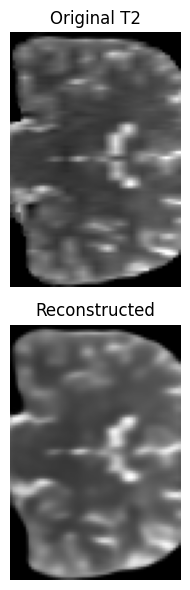

In [ ]:
checkpoint = torch.load("/content/drive/MyDrive/fyp_checkpoints/autoencoder_best.pth", map_location=device)

autoencoder.load_state_dict(checkpoint["autoencoder_state_dict"])
autoencoder.to(device)

visualize_reconstructions(autoencoder, val_loader, device)

# Define diffusion model

After training the autoencoder on T2 volumes, the encoder is frozen and used to map both T1 and T2 images into a shared latent space. During diffusion training, Gaussian noise is added to the latent representation of the target T2 image at a randomly sampled timestep. The latent representation of the paired T1 image is concatenated with the noisy T2 latent and provided as conditional input to a 3D diffusion U-Net. The network is optimized to predict the injected noise using mean squared error loss, thereby learning to iteratively denoise the T2 latent under T1 guidance.

In [13]:
import os
import torch
import torch.nn.functional as F
from tqdm import tqdm
from torch.amp import autocast, GradScaler
from generative.networks.nets import DiffusionModelUNet
from generative.networks.schedulers import DDPMScheduler

In [14]:
# load trained autoencoder
ae_ckpt_path = "/content/drive/MyDrive/fyp_checkpoints/autoencoder_best.pth"

checkpoint = torch.load(ae_ckpt_path, map_location=device)

# Case 1: full checkpoint dict
if "autoencoder_state_dict" in checkpoint:
    autoencoder.load_state_dict(checkpoint["autoencoder_state_dict"])
else:
    # Case 2: only weights saved
    autoencoder.load_state_dict(checkpoint)

print("Autoencoder weights loaded successfully.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Freeze autoencoder
autoencoder.eval()
for p in autoencoder.parameters():
    p.requires_grad = False


Autoencoder weights loaded successfully.
Using device: cuda


In [35]:
# define latent diffusion model
latent_channels = 8  # must match your trained autoencoder latent channels

unet = DiffusionModelUNet(
    spatial_dims=3,
    in_channels=latent_channels * 2,   # noisy z_t2 + z_t1
    out_channels=latent_channels,      # predict noise for z_t2
    num_res_blocks=2,
    num_channels=(64, 128, 256),
    attention_levels=(False, True, True),
    num_head_channels=(0, 64, 128),
).to(device)

scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    schedule="scaled_linear_beta",
    beta_start=0.0015,
    beta_end=0.0195,
)

optimizer_diff = torch.optim.AdamW(unet.parameters(), lr=8e-5, weight_decay=1e-6)

# optional LR scheduler
scheduler_lr = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_diff,
    mode="min",
    factor=0.5,
    patience=5
)

scaler = GradScaler(enabled=(device.type == "cuda"))

In [20]:
import copy

ema_unet = copy.deepcopy(unet).to(device)
ema_unet.eval()

for p in ema_unet.parameters():
    p.requires_grad = False

In [21]:
@torch.no_grad()
def update_ema(ema_model, model, decay=0.999):
    ema_params = dict(ema_model.named_parameters())
    model_params = dict(model.named_parameters())

    for name in ema_params:
        ema_params[name].mul_(decay).add_(model_params[name], alpha=1.0 - decay)

    # also keep buffers in sync if any
    ema_buffers = dict(ema_model.named_buffers())
    model_buffers = dict(model.named_buffers())

    for name in ema_buffers:
        ema_buffers[name].copy_(model_buffers[name])

In [18]:
autoencoder.eval()
latents_std = []

with torch.no_grad():
    for i, batch in enumerate(train_loader):
        t2_sample = batch["t2"].to(device)
        z = autoencoder.encode_stage_2_inputs(t2_sample)
        latents_std.append(z.std().item())
        if i >= 9:
            break

scale_factor = 1.0 / np.mean(latents_std)
print(f"Scale factor: {scale_factor:.6f}")

Scale factor: 0.992187


In [22]:
def encode_latents(autoencoder, t1, t2, scale_factor):
    with torch.no_grad():
        z_t1 = autoencoder.encode_stage_2_inputs(t1) * scale_factor
        z_t2 = autoencoder.encode_stage_2_inputs(t2) * scale_factor
    return z_t1, z_t2


def train_one_epoch(autoencoder, unet, ema_unet, noise_scheduler, train_loader, optimizer, scaler, device, scale_factor, grad_clip=1.0):
    unet.train()
    ema_unet.eval()
    running_loss = 0.0

    pbar = tqdm(train_loader, ncols=120, desc="Training")

    for step, batch in enumerate(pbar):
        t1 = batch["t1"].to(device, non_blocking=True)
        t2 = batch["t2"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        z_t1, z_t2 = encode_latents(autoencoder, t1, t2, scale_factor)

        noise = torch.randn_like(z_t2)
        timesteps = torch.randint(
            low=0,
            high=noise_scheduler.num_train_timesteps,
            size=(z_t2.shape[0],),
            device=device
        ).long()

        noisy_z_t2 = noise_scheduler.add_noise(
            original_samples=z_t2,
            noise=noise,
            timesteps=timesteps
        )

        model_input = torch.cat([noisy_z_t2, z_t1], dim=1)

        with autocast(device_type="cuda", enabled=(device.type == "cuda")):
            noise_pred = unet(model_input, timesteps=timesteps)
            loss = F.mse_loss(noise_pred.float(), noise.float())

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=grad_clip)

        scaler.step(optimizer)
        scaler.update()

        update_ema(ema_unet, unet, decay=0.999)

        running_loss += loss.item()
        avg_loss = running_loss / (step + 1)
        pbar.set_postfix(train_loss=f"{avg_loss:.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    return running_loss / len(train_loader)


@torch.no_grad()
def validate_one_epoch(autoencoder, eval_unet, noise_scheduler, val_loader, device, scale_factor, seed=42):
    eval_unet.eval()
    running_loss = 0.0

    g = torch.Generator(device=device)
    g.manual_seed(seed)

    pbar = tqdm(val_loader, ncols=120, desc="Validation")

    for step, batch in enumerate(pbar):
        t1 = batch["t1"].to(device, non_blocking=True)
        t2 = batch["t2"].to(device, non_blocking=True)

        z_t1, z_t2 = encode_latents(autoencoder, t1, t2, scale_factor)

        noise = torch.randn(z_t2.shape, generator=g, device=device, dtype=z_t2.dtype)
        timesteps = torch.randint(
            low=0,
            high=noise_scheduler.num_train_timesteps,
            size=(z_t2.shape[0],),
            generator=g,
            device=device
        ).long()

        noisy_z_t2 = noise_scheduler.add_noise(
            original_samples=z_t2,
            noise=noise,
            timesteps=timesteps
        )

        model_input = torch.cat([noisy_z_t2, z_t1], dim=1)

        with autocast(device_type="cuda", enabled=(device.type == "cuda")):
            noise_pred = eval_unet(model_input, timesteps=timesteps)
            loss = F.mse_loss(noise_pred.float(), noise.float())

        running_loss += loss.item()
        avg_loss = running_loss / (step + 1)
        pbar.set_postfix(val_loss=f"{avg_loss:.4f}")

    return running_loss / len(val_loader)


In [23]:
n_epochs = 100

train_loss_list = []
val_loss_list = []
best_val_loss = float("inf")
start_epoch = 0

save_dir = "/content/drive/MyDrive/fyp_checkpoints"
os.makedirs(save_dir, exist_ok=True)

latest_ckpt_path = os.path.join(save_dir, "latent_diffusion_latest.pth")
best_ckpt_path = os.path.join(save_dir, "latent_diffusion_best.pth")

for epoch in range(start_epoch, n_epochs):
    print(f"\nEpoch {epoch + 1}/{n_epochs}")

    train_loss = train_one_epoch(
        autoencoder=autoencoder,
        unet=unet,
        ema_unet=ema_unet,
        noise_scheduler=scheduler,
        train_loader=train_loader,
        optimizer=optimizer_diff,
        scaler=scaler,
        device=device,
        scale_factor=scale_factor,
        grad_clip=1.0,
    )

    val_loss = validate_one_epoch(
        autoencoder=autoencoder,
        eval_unet=ema_unet,
        noise_scheduler=scheduler,
        val_loader=val_loader,
        device=device,
        scale_factor=scale_factor,
        seed=1234,
    )

    scheduler_lr.step(val_loss)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {epoch + 1}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}")

    checkpoint = {
        "epoch": epoch + 1,
        "unet_state_dict": unet.state_dict(),
        "ema_unet_state_dict": ema_unet.state_dict(),
        "optimizer_diff_state_dict": optimizer_diff.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "train_loss_list": train_loss_list,
        "val_loss_list": val_loss_list,
        "best_val_loss": best_val_loss,
        "scale_factor": scale_factor,
        "latent_channels": latent_channels,
    }

    torch.save(checkpoint, latest_ckpt_path)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint["best_val_loss"] = best_val_loss
        torch.save(checkpoint, best_ckpt_path)
        print(f"Best model saved at epoch {epoch + 1} with val_loss={val_loss:.6f}")


Epoch 1/100


Validation: 100%|██████████████████████████████████████████████████████| 49/49 [00:09<00:00,  5.07it/s, val_loss=0.9270]


Epoch 1: train_loss=0.367431, val_loss=0.926971
Best model saved at epoch 1 with val_loss=0.926971

Epoch 2/100


Validation: 100%|██████████████████████████████████████████████████████| 49/49 [00:09<00:00,  5.37it/s, val_loss=0.8159]


Epoch 2: train_loss=0.156478, val_loss=0.815884
Best model saved at epoch 2 with val_loss=0.815884

Epoch 3/100


...

Epoch 49: train_loss=nan, val_loss=0.083622

Epoch 50/100


Validation: 100%|██████████████████████████████████████████████████████| 49/49 [00:09<00:00,  5.22it/s, val_loss=0.0895]


Epoch 50: train_loss=nan, val_loss=0.089526

Epoch 51/100


Training:  25%|███████████                                 | 25/99 [00:22<01:06,  1.11it/s, lr=5.00e-04, train_loss=nan]


KeyboardInterrupt: 

Inference Code

In [36]:
ae_ckpt_path = "/content/drive/MyDrive/fyp_checkpoints/autoencoder_best.pth"
diff_ckpt_path = "/content/drive/MyDrive/fyp_checkpoints/latent_diffusion_best.pth"

# Load autoencoder
print(f"Loading Autoencoder from: {ae_ckpt_path}")
ae_checkpoint = torch.load(ae_ckpt_path, map_location=device, weights_only=False)
if "autoencoder_state_dict" in ae_checkpoint:
    autoencoder.load_state_dict(ae_checkpoint["autoencoder_state_dict"])
else:
    autoencoder.load_state_dict(ae_checkpoint) # Case: only weights saved

autoencoder.to(device)
autoencoder.eval()
for p in autoencoder.parameters():
    p.requires_grad = False
print("Autoencoder loaded and frozen.")

# Load latent diffusion UNet
print(f"Loading Latent Diffusion UNet from: {diff_ckpt_path}")
diff_checkpoint = torch.load(diff_ckpt_path, map_location=device, weights_only=False)
unet.load_state_dict(diff_checkpoint["unet_state_dict"])
ema_unet.load_state_dict(diff_checkpoint["ema_unet_state_dict"])

unet.to(device)
unet.eval()
ema_unet.to(device)
ema_unet.eval()

# Restore scale_factor, latent_channels from checkpoint if needed, otherwise use existing
if "scale_factor" in diff_checkpoint:
    scale_factor = diff_checkpoint["scale_factor"]
    print(f"Scale factor loaded from checkpoint: {scale_factor:.6f}")
if "latent_channels" in diff_checkpoint:
    latent_channels = diff_checkpoint["latent_channels"]
    print(f"Latent channels loaded from checkpoint: {latent_channels}")

print("Latent Diffusion UNet and EMA UNet loaded and set to eval mode.")

Loading Autoencoder from: /content/drive/MyDrive/fyp_checkpoints/autoencoder_best.pth
Autoencoder loaded and frozen.
Loading Latent Diffusion UNet from: /content/drive/MyDrive/fyp_checkpoints/latent_diffusion_best.pth
Scale factor loaded from checkpoint: 0.996017
Latent channels loaded from checkpoint: 8
Latent Diffusion UNet and EMA UNet loaded and set to eval mode.


In [26]:
@torch.no_grad()
def generate_t2_from_t1(
    t1,
    autoencoder,
    unet,
    scheduler,
    scale_factor,
    device,
    num_inference_steps=250,
):
    autoencoder.eval()
    for p in autoencoder.parameters():
      p.requires_grad = False
    unet.eval()

    t1 = t1.to(device)

    # Encode T1 to latent
    z_t1 = autoencoder.encode_stage_2_inputs(t1) * scale_factor

    # Start from pure noise for target T2 latent
    latent = torch.randn_like(z_t1, device=device)

    scheduler.set_timesteps(num_inference_steps=num_inference_steps)

    for t in scheduler.timesteps:
        if not torch.is_tensor(t):
            t = torch.tensor(t, device=device)

        timesteps = torch.full(
            (latent.shape[0],), t, device=device, dtype=torch.long
        )

        # Condition on T1 latent
        model_input = torch.cat([latent, z_t1], dim=1)

        noise_pred = unet(model_input, timesteps=timesteps)
        if hasattr(noise_pred, "sample"):
            noise_pred = noise_pred.sample

        step_output = scheduler.step(noise_pred, t, latent)
        latent = step_output[0] if isinstance(step_output, tuple) else step_output.prev_sample

    # Decode back to image space
    latent = latent / scale_factor
    pred_t2 = autoencoder.decode_stage_2_outputs(latent)
    pred_t2 = torch.clamp(pred_t2, -1.0, 1.0)

    return pred_t2

In [37]:
# run inference on one batch
batch = next(iter(val_loader))   # or test_loader
t1 = batch["t1"].to(device)
t2 = batch["t2"].to(device)  # ground truth, only for comparison

pred_t2 = generate_t2_from_t1(
    t1=t1,
    autoencoder=autoencoder,
    unet=ema_unet,
    scheduler=scheduler,
    scale_factor=scale_factor,
    device=device,
    num_inference_steps=1000,
)

print("T1 shape      :", t1.shape)
print("Pred T2 shape :", pred_t2.shape)
print("GT T2 shape   :", t2.shape)

T1 shape      : torch.Size([1, 1, 96, 96, 64])
Pred T2 shape : torch.Size([1, 1, 96, 96, 64])
GT T2 shape   : torch.Size([1, 1, 96, 96, 64])


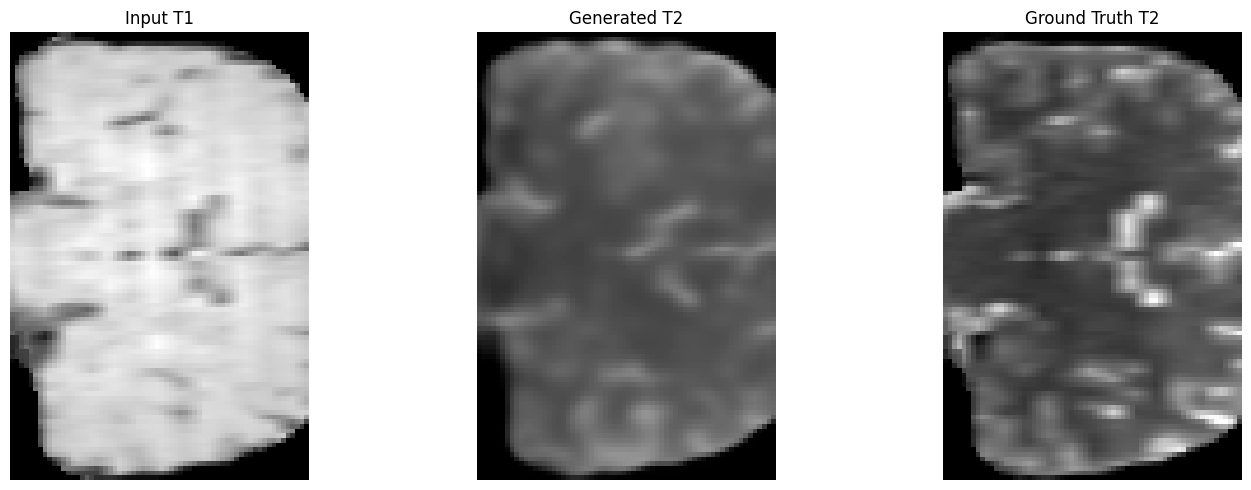

In [38]:
# visualize a middle slice to see if the genration is reasonable
import matplotlib.pyplot as plt
def to_display_range(x):
    x = torch.clamp(x, -1.0, 1.0)
    return (x + 1.0) / 2.0


def show_middle_slice(t1, pred_t2, gt_t2, sample_idx=0):
    t1_disp = to_display_range(t1)
    pred_disp = to_display_range(pred_t2)
    gt_disp = to_display_range(gt_t2)

    t1_np = t1_disp[sample_idx, 0].detach().cpu().numpy()
    pred_np = pred_disp[sample_idx, 0].detach().cpu().numpy()
    gt_np = gt_disp[sample_idx, 0].detach().cpu().numpy()

    mid = t1_np.shape[0] // 2

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(t1_np[mid], cmap="gray", vmin=0, vmax=1)
    plt.title("Input T1")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(pred_np[mid], cmap="gray", vmin=0, vmax=1)
    plt.title("Generated T2")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(gt_np[mid], cmap="gray", vmin=0, vmax=1)
    plt.title("Ground Truth T2")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_middle_slice(t1, pred_t2, t2, sample_idx=0)

In [29]:
#save generated T2 volume as nifti
import os
import nibabel as nib
import numpy as np

def save_nifti_volume(volume_tensor, save_path, rescale_to_01=False):
    vol = volume_tensor.detach().cpu().numpy()

    if vol.ndim == 4:
        vol = vol[0]

    if rescale_to_01:
        vol = np.clip(vol, -1.0, 1.0)
        vol = (vol + 1.0) / 2.0

    vol = vol.astype(np.float32)
    nii = nib.Nifti1Image(vol, affine=np.eye(4))
    nib.save(nii, save_path)

In [ ]:
save_dir = "/content/drive/MyDrive/fyp_generated_t2"
os.makedirs(save_dir, exist_ok=True)

save_nifti_volume(pred_t2[0], os.path.join(save_dir, "sample_pred_t2.nii.gz"))
save_nifti_volume(t2[0], os.path.join(save_dir, "sample_gt_t2.nii.gz"))
save_nifti_volume(t1[0], os.path.join(save_dir, "sample_input_t1.nii.gz"))

In [39]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_list = []
ssim_list = []

unet.eval()
autoencoder.eval()
for p in autoencoder.parameters():
    p.requires_grad = False

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        t1 = batch["t1"].to(device)
        gt_t2 = batch["t2"].to(device)

        pred_t2 = generate_t2_from_t1(
            t1=t1,
            autoencoder=autoencoder,
            unet=unet,
            scheduler=scheduler,
            scale_factor=scale_factor,
            device=device,
            num_inference_steps=1000,
        )

        pred_np = pred_t2.cpu().numpy()
        gt_np = gt_t2.cpu().numpy()

        B = pred_np.shape[0]

        batch_psnr = []
        batch_ssim = []

        for i in range(B):
            pred_vol = pred_np[i, 0]
            gt_vol = gt_np[i, 0]

            # Normalize
            pred_vol = np.clip(pred_vol, -1.0, 1.0)
            gt_vol = np.clip(gt_vol, -1.0, 1.0)

            pred_vol = (pred_vol + 1.0) / 2.0
            gt_vol = (gt_vol + 1.0) / 2.0

            # PSNR
            psnr_val = psnr(gt_vol, pred_vol, data_range=1.0)

            # SSIM (slice-wise)
            ssim_slices = []
            for z in range(pred_vol.shape[0]):
                ssim_val = ssim(
                    gt_vol[z],
                    pred_vol[z],
                    data_range=1.0
                )
                ssim_slices.append(ssim_val)

            ssim_val = np.mean(ssim_slices)

            # store
            psnr_list.append(psnr_val)
            ssim_list.append(ssim_val)

            batch_psnr.append(psnr_val)
            batch_ssim.append(ssim_val)

        # ✅ Print batch result
        print(
            f"Batch {batch_idx:03d} | "
            f"PSNR: {np.mean(batch_psnr):.2f} | "
            f"SSIM: {np.mean(batch_ssim):.4f}"
        )

# Final results
print("\n===== FINAL RESULTS =====")
print(f"Mean PSNR: {np.mean(psnr_list):.4f}")
print(f"Mean SSIM: {np.mean(ssim_list):.4f}")

Batch 000 | PSNR: 16.90 | SSIM: 0.6062
Batch 001 | PSNR: 16.13 | SSIM: 0.5764
Batch 002 | PSNR: 18.71 | SSIM: 0.5838
Batch 003 | PSNR: 17.95 | SSIM: 0.5450
Batch 004 | PSNR: 15.32 | SSIM: 0.6072
Batch 005 | PSNR: 17.40 | SSIM: 0.5316
Batch 006 | PSNR: 16.52 | SSIM: 0.5693
Batch 007 | PSNR: 18.96 | SSIM: 0.6397
Batch 008 | PSNR: 18.26 | SSIM: 0.5764
Batch 009 | PSNR: 15.90 | SSIM: 0.5748
Batch 010 | PSNR: 15.92 | SSIM: 0.5892
Batch 011 | PSNR: 18.43 | SSIM: 0.5948
Batch 012 | PSNR: 11.20 | SSIM: 0.5505
Batch 013 | PSNR: 17.71 | SSIM: 0.6320
Batch 014 | PSNR: 18.48 | SSIM: 0.6166
Batch 015 | PSNR: 14.93 | SSIM: 0.5636
Batch 016 | PSNR: 18.81 | SSIM: 0.6453
Batch 017 | PSNR: 18.53 | SSIM: 0.6327
Batch 018 | PSNR: 18.92 | SSIM: 0.5672
Batch 019 | PSNR: 17.71 | SSIM: 0.5966
Batch 020 | PSNR: 16.22 | SSIM: 0.5757
Batch 021 | PSNR: 18.31 | SSIM: 0.5728
Batch 022 | PSNR: 18.68 | SSIM: 0.6215
Batch 023 | PSNR: 19.07 | SSIM: 0.6129
Batch 024 | PSNR: 16.31 | SSIM: 0.5939
Batch 025 | PSNR: 17.81 |

In [ ]:
# generate for the whole test set
import os

save_dir = "/content/drive/MyDrive/fyp_generated_t2"
os.makedirs(save_dir, exist_ok=True)

unet.eval()
autoencoder.eval()

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        t1 = batch["t1"].to(device)

        pred_t2 = generate_t2_from_t1(
            t1=t1,
            autoencoder=autoencoder,
            unet=unet,
            scheduler=scheduler,
            scale_factor=scale_factor,
            device=device,
            num_inference_steps=1000,
        )

        for i in range(pred_t2.shape[0]):
            filename = f"test_batch{batch_idx:03d}_sample{i:02d}_pred_t2.nii.gz"
            save_path = os.path.join(save_dir, filename)
            save_nifti_volume(pred_t2[i], save_path)

Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch000_sample00_pred_t2.nii.gz
Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch001_sample00_pred_t2.nii.gz
Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch002_sample00_pred_t2.nii.gz
Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch003_sample00_pred_t2.nii.gz
Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch004_sample00_pred_t2.nii.gz
Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch005_sample00_pred_t2.nii.gz
Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch006_sample00_pred_t2.nii.gz
Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch007_sample00_pred_t2.nii.gz
Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch008_sample00_pred_t2.nii.gz
Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch009_sample00_pred_t2.nii.gz
Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch010_sample00_pred_t2.nii.gz
Saved: /content/drive/MyDrive/fyp_generated_t2/test_batch011_samp

KeyboardInterrupt: 